# Experimento: Visualización del MAP vs Mediana
En este notebook superponemos la configuración de máxima probabilidad (MAP) sobre el corner plot utilizando puntos azules, manteniendo intactos los puntos rojos y las medianas calculadas por defecto. Además, forzamos que el diagrama esquemático del anillo refleje los parámetros del MAP.

In [4]:
import sys
import numpy as np
from pathlib import Path

# Añadir pipeline al path
sys.path.insert(0, str(Path('../../pipeline').resolve()))

import photoring.plotting as plot
import dynesty.plotting as dyplot

### Monkey Patching Avanzado
Aquí realizamos dos intercepciones:
1. Interceptamos `plot_corner_reduced` para añadir puntos azules (MAP) en los paneles 2D justo después de generarse el gráfico base.
2. Interceptamos `plot_ring_diagram` para inyectar los parámetros del MAP (en lugar de la mediana) únicamente durante la construcción del dibujo esquemático.

In [5]:
# Restaurar originales si existían
if hasattr(plot, 'original_plot_corner_reduced'):
    plot.plot_corner_reduced = plot.original_plot_corner_reduced

import dynesty.plotting as dyplot
if not hasattr(dyplot, 'original_cornerplot'):
    dyplot.original_cornerplot = dyplot.cornerplot

def cornerplot_map_override(results, **kwargs):
    # Obtener el índice MAP
    map_idx = np.argmax(results['logl'])
    map_params = results['samples'][map_idx]
    
    # dynesty's cornerplot podría recibir dims para plotear solo un subconjunto
    dims = kwargs.get('dims')
    if dims is not None:
        truths = [map_params[d] for d in dims]
    else:
        truths = map_params
        
    # Pasar los truths filtrados a dynesty con color azul
    return dyplot.original_cornerplot(results, truths=truths, truth_color='blue', **kwargs)

dyplot.cornerplot = cornerplot_map_override

# Extractor MAP para el diagrama de anillos
def get_ring_diagram_values_map(run):
    chain = run["chain"]
    pnames = run["param_names"]
    meta = run["meta"]
    map_idx = np.argmax(run["logl"])
    map_params = chain[map_idx]
    
    def _get(name, default):
        return map_params[pnames.index(name)] if name in pnames else default

    p_fixed = meta.get("P_FIXED_VALUE", meta.get("p_min", meta.get("p_mean_ref", 0.08)))
    tau_fixed = meta.get("TAU_FIXED", 0.5)

    return dict(
        fe=float(_get("fe", meta.get("FE_MAX", 5.0) / 2)),
        ir=float(_get("ir", 45.0)),
        theta=float(_get("theta", 90.0)),
        p=float(_get("p", p_fixed)),
        tau=float(_get("tau", tau_fixed)),
    )

if not hasattr(plot, 'original_plot_ring_diagram'):
    plot.original_plot_ring_diagram = plot.plot_ring_diagram

def plot_ring_diagram_map(run, ax=None, paths=None, scale=0.2, dx=0.0):
    original_get_ring_diagram_values = plot._get_ring_diagram_values
    try:
        plot._get_ring_diagram_values = get_ring_diagram_values_map
        plot.original_plot_ring_diagram(run, ax=ax, paths=paths, scale=scale, dx=dx)
    finally:
        plot._get_ring_diagram_values = original_get_ring_diagram_values
        
plot.plot_ring_diagram = plot_ring_diagram_map

print("Monkey patching restaurado para dibujar líneas (dyplot.cornerplot) en azul.")


Monkey patching restaurado para dibujar líneas (dyplot.cornerplot) en azul.


/var/folders/xn/75ncx53144919w099wx5x5mw0000gn/T/ipykernel_49098/1516423955.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


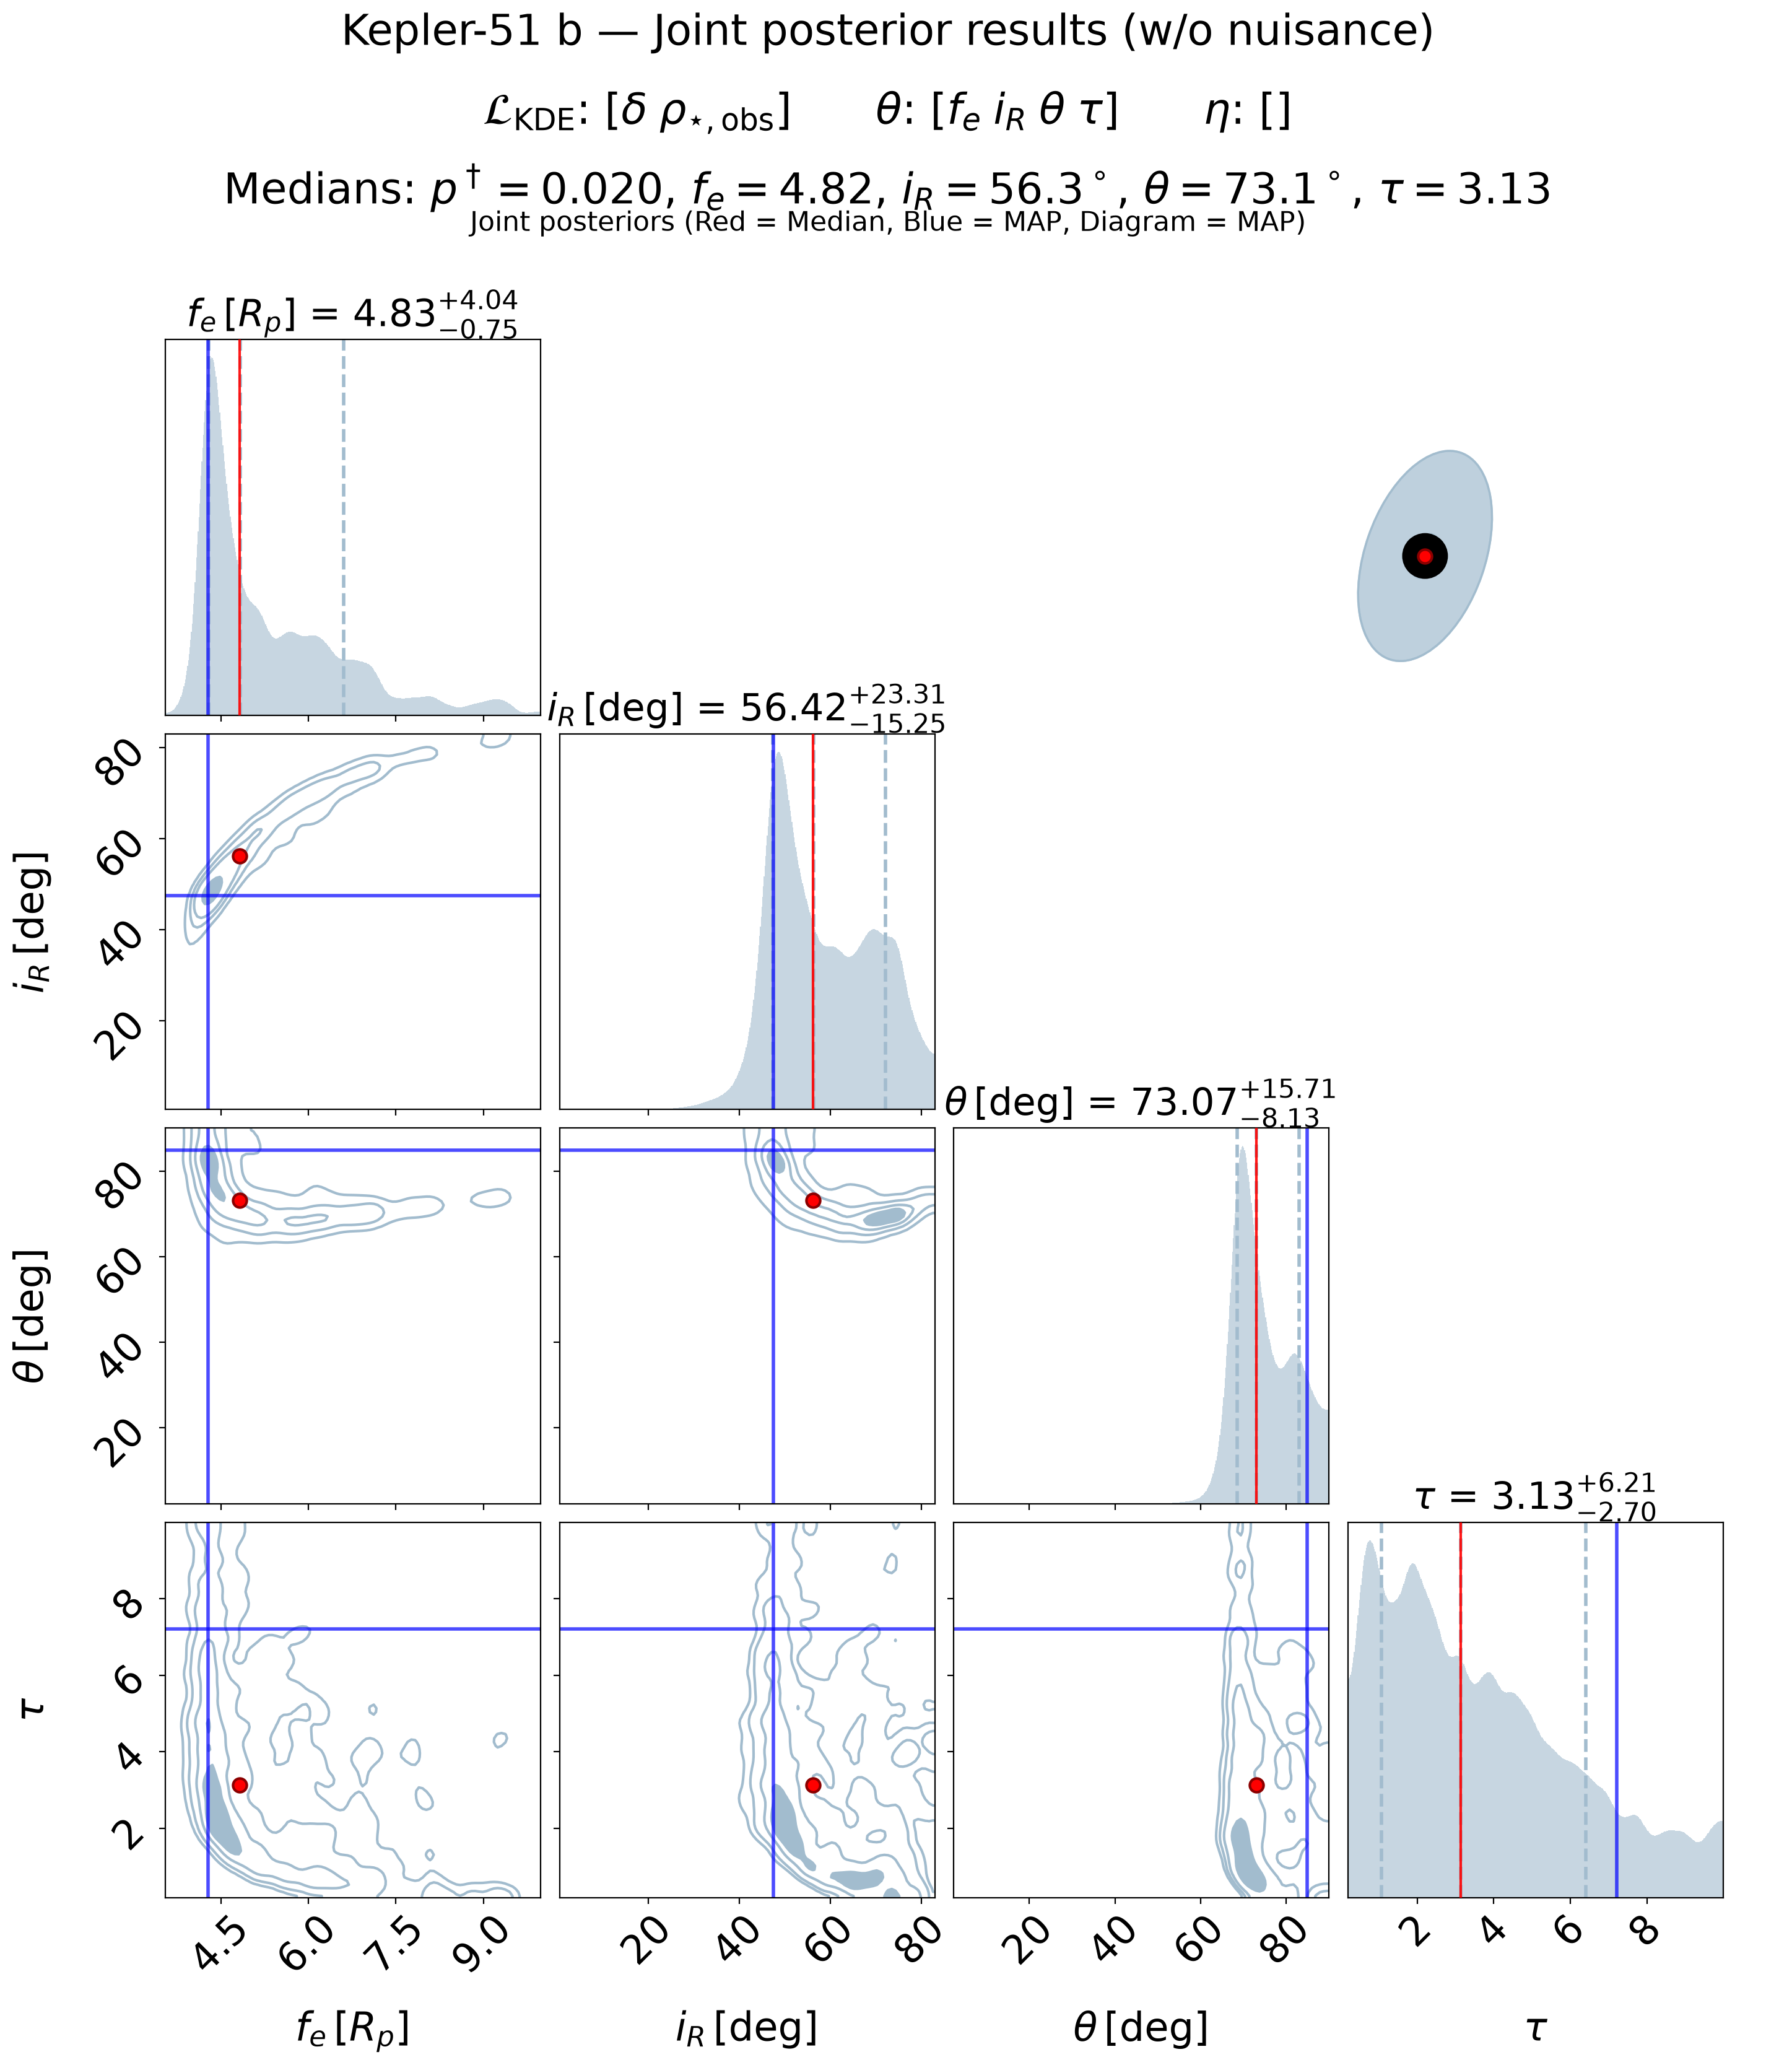

In [6]:
from photoring.io import load_run
import glob

# Cargar un run de ejemplo para probarlo
files = glob.glob('../../pipeline/kepler_51/results/exorings/kepler_51_b_NS_exorings_kde_delta*.npz')
if files:
    run_path = files[0]
    run = load_run(run_path)
    
    fig = plot.plot_results_panel_reduced_inset(run, title=True)
    fig.suptitle('Joint posteriors (Red = Median, Blue = MAP, Diagram = MAP)', fontsize=16, y=1.03)
    fig.show()
else:
    print("No se encontraron runs.")


### Analizando un caso adicional
El usuario solicitó revisar el caso específico: `kepler_51_b_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE.npz`

Cargado: kepler_51_b_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE.npz
LogL MAP: 14.73 en el índice 17954


/var/folders/xn/75ncx53144919w099wx5x5mw0000gn/T/ipykernel_49098/3939663.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


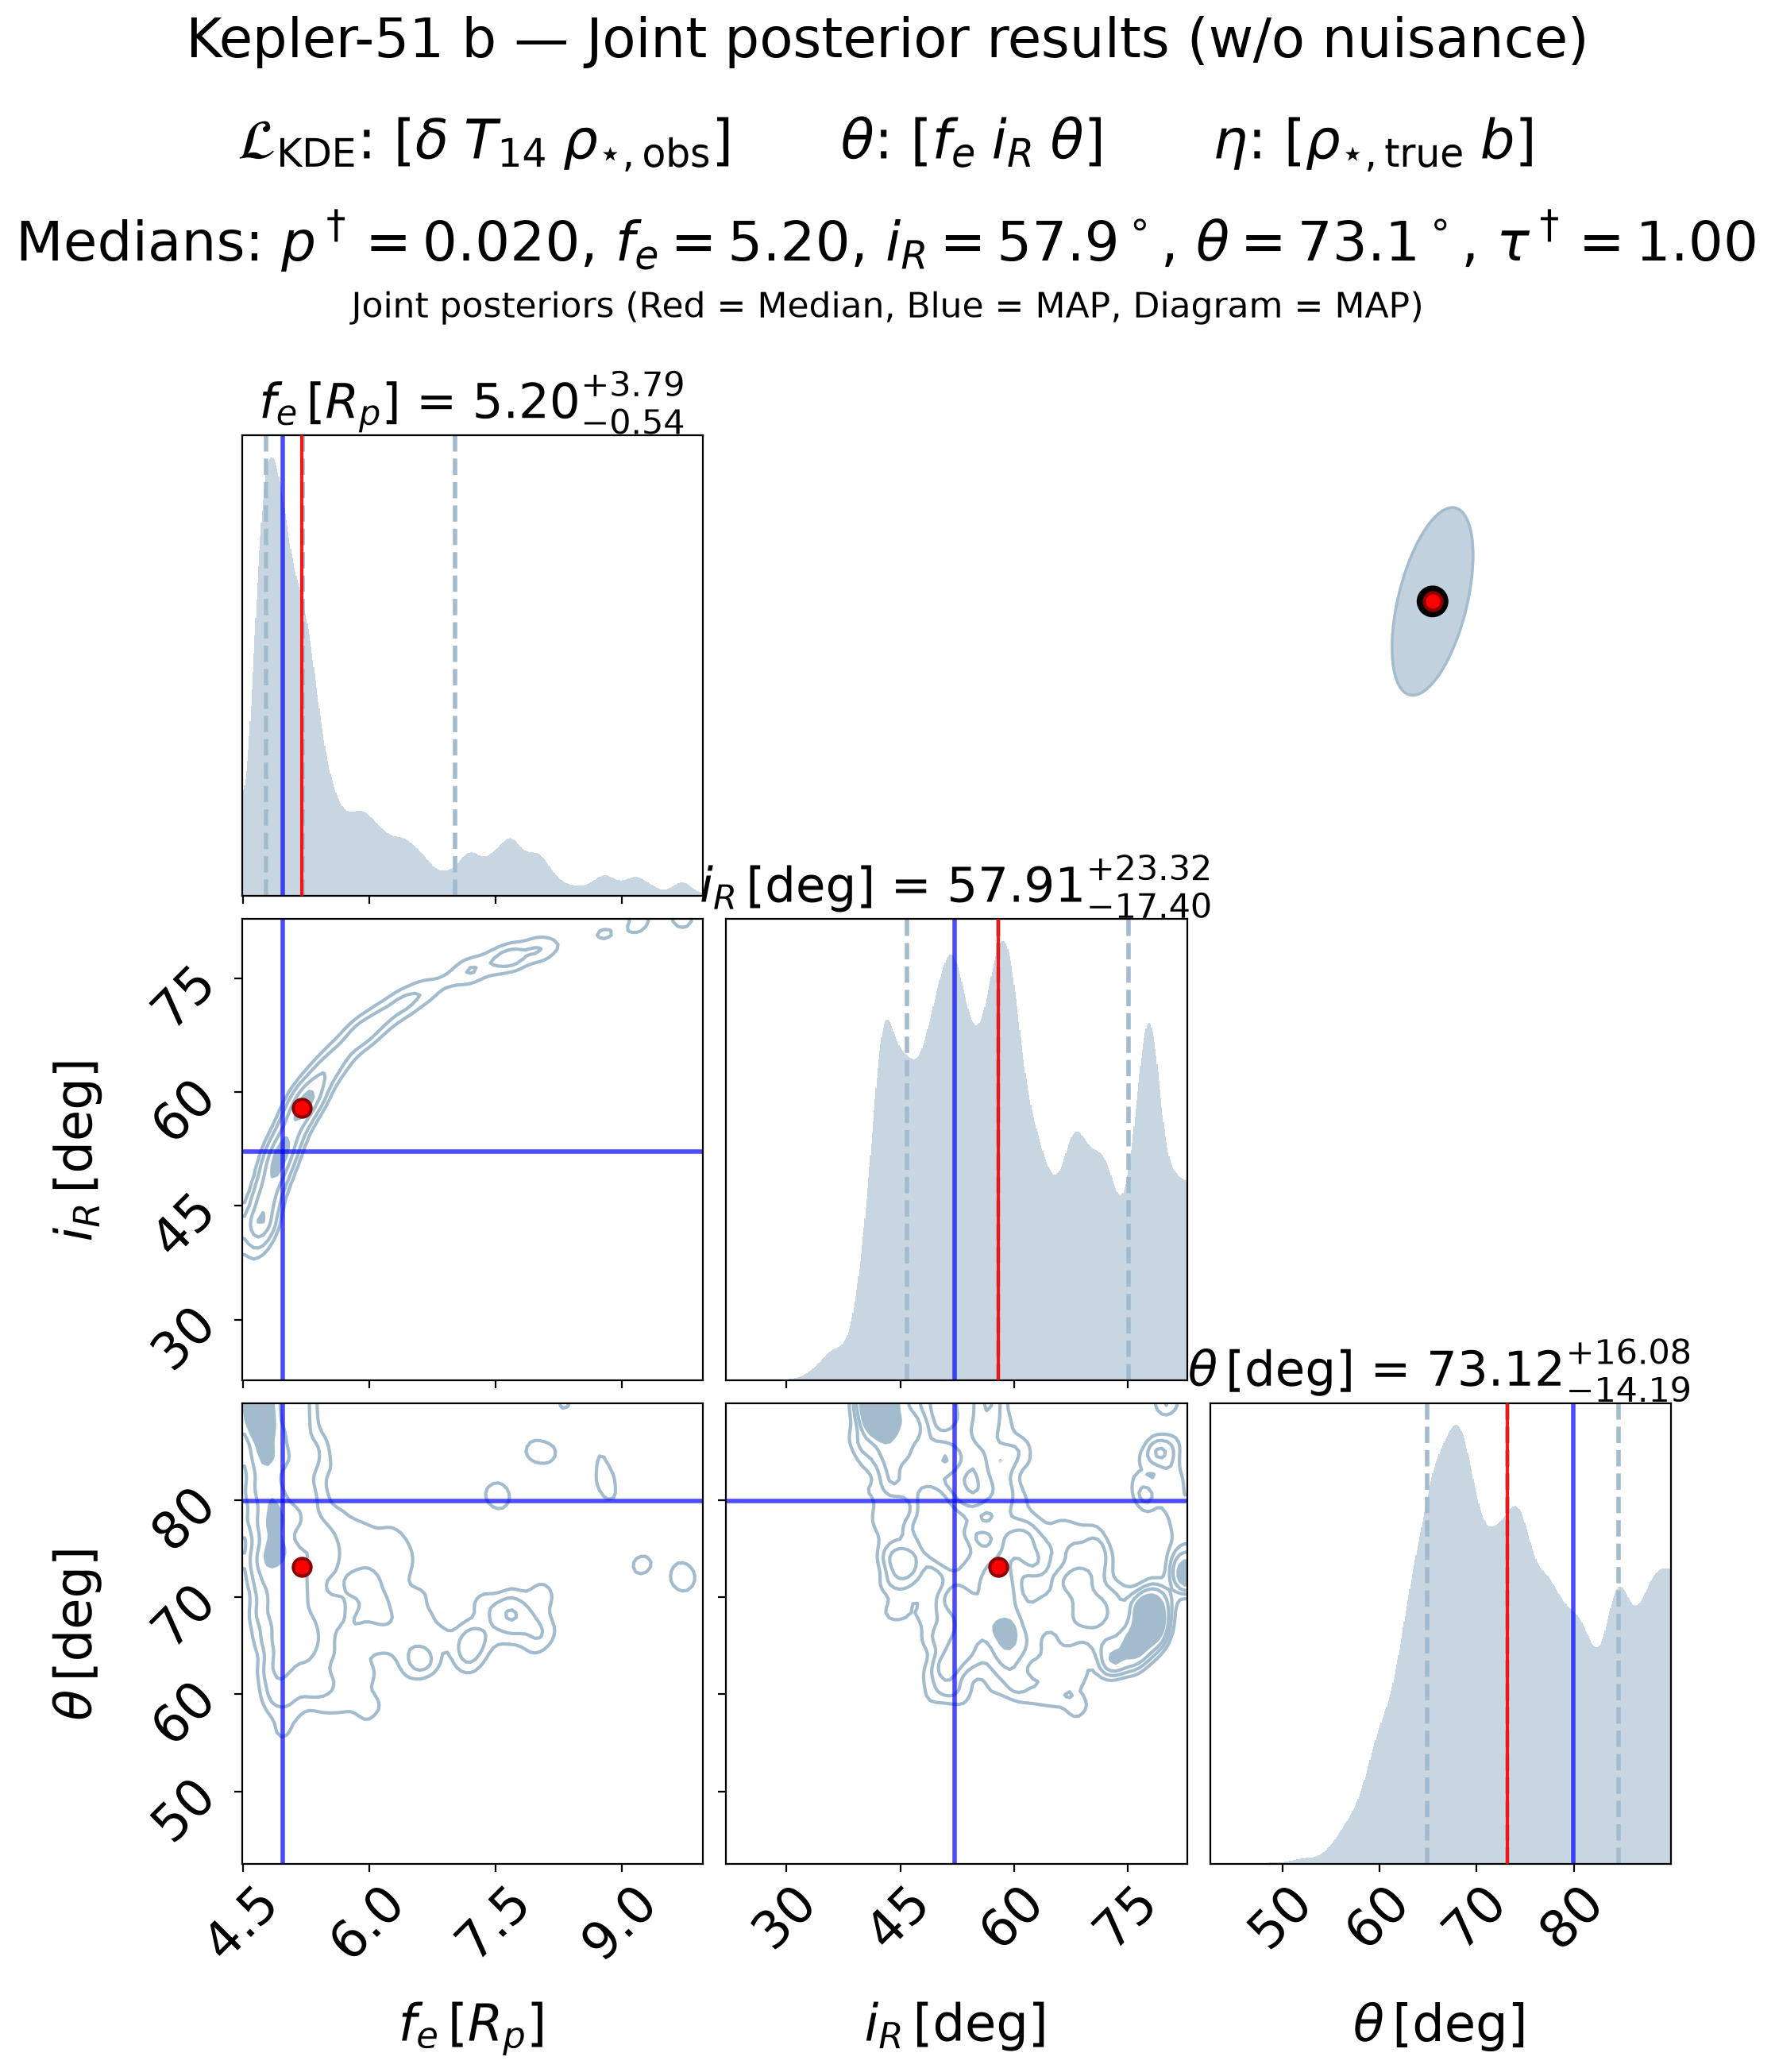

In [7]:
from pathlib import Path
import os

run_path_2 = '../../pipeline/kepler_51/results/exorings/kepler_51_b_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE.npz'

if os.path.exists(run_path_2):
    run2 = load_run(run_path_2)
    print(f"Cargado: {Path(run_path_2).name}")
    map_idx2 = np.argmax(run2['logl'])
    print(f"LogL MAP: {run2['logl'][map_idx2]:.2f} en el índice {map_idx2}")
    
    # Dibujar la figura
    fig2 = plot.plot_results_panel_reduced_inset(run2, title=True)
    fig2.suptitle('Joint posteriors (Red = Median, Blue = MAP, Diagram = MAP)', fontsize=16, y=1.03)
    fig2.show()
else:
    print(f"No se encontró el archivo: {run_path_2}")
